<a href="https://colab.research.google.com/github/ss48/opencv/blob/master/OpenCV_ML2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MNIST gives you the handwritten digit images. https://archive.ics.uci.edu/dataset/683/mnist


OpenCV is used to clean each image a little with blur and thresholding.

Each image is then converted into a 784-value vector.

A logistic regression classifier learns to map those pixel values to digit labels.

The test set checks how well the model generalizes.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)
Label: 5


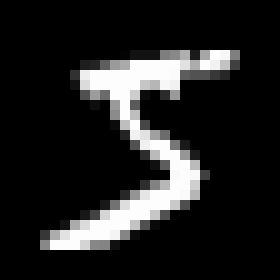

Processed training shape: (60000, 784)
Processed test shape: (10000, 784)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.9261

Classification report:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       980
           1       0.97      0.98      0.97      1135
           2       0.93      0.90      0.92      1032
           3       0.90      0.91      0.91      1010
           4       0.93      0.93      0.93       982
           5       0.90      0.87      0.88       892
           6       0.93      0.95      0.94       958
           7       0.93      0.92      0.93      1028
           8       0.90      0.90      0.90       974
           9       0.91      0.91      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.92     10000
weighted avg       0.93      0.93      0.93     10000



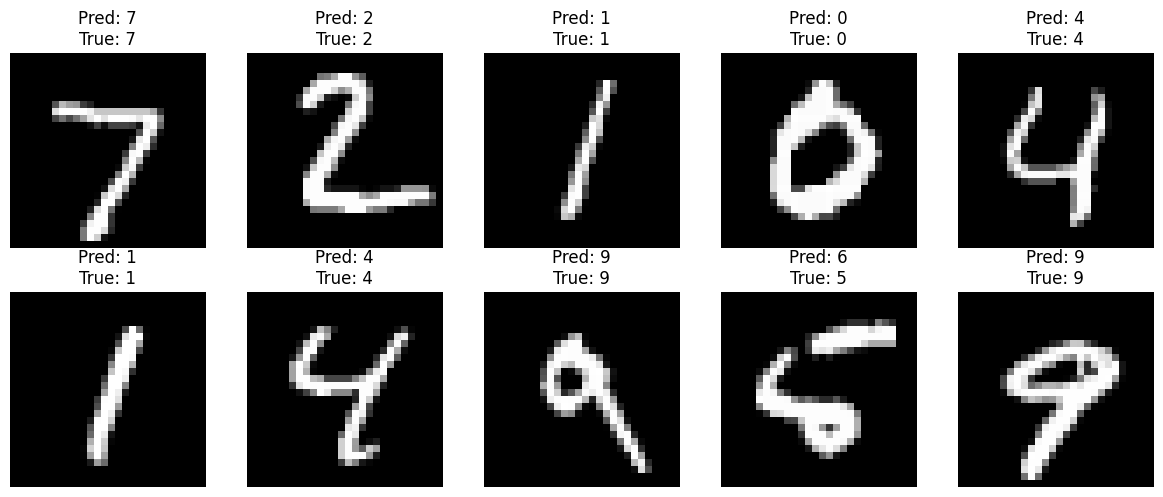

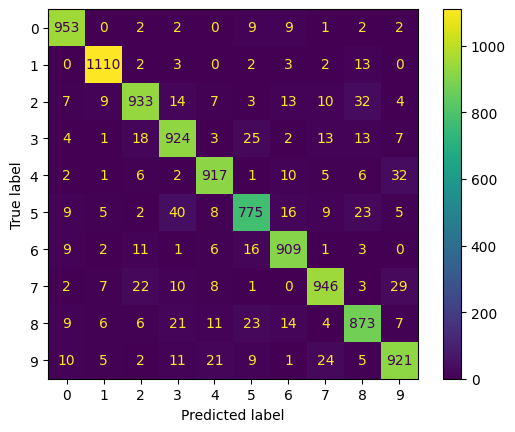

In [2]:
!pip install -q opencv-python-headless tensorflow scikit-learn matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab.patches import cv2_imshow
from tensorflow.keras.datasets import mnist
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# 1. Load MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

# 2. Show one sample
sample = x_train[0]
label = y_train[0]
big_sample = cv2.resize(sample, (280, 280), interpolation=cv2.INTER_NEAREST)
print("Label:", label)
cv2_imshow(big_sample)

# 3. Preprocess with OpenCV
def preprocess_images(images):
    processed = []

    for img in images:
        blurred = cv2.GaussianBlur(img, (3, 3), 0)
        _, thresh = cv2.threshold(
            blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )
        processed.append(thresh.flatten())

    return np.array(processed, dtype=np.float32)

X_train = preprocess_images(x_train)
X_test = preprocess_images(x_test)

# 4. Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Processed training shape:", X_train.shape)
print("Processed test shape:", X_test.shape)

# 5. Train model
model = LogisticRegression(max_iter=1000, solver="lbfgs", multi_class="auto")
model.fit(X_train, y_train)

# 6. Predict
y_pred = model.predict(X_test)

# 7. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

# 8. Show predictions
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"Pred: {y_pred[i]}\nTrue: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# 9. Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()


What changed from the earlier ML version?

The earlier version used flattened pixels + logistic regression. This version uses a CNN, which keeps the image as a 2D grid and learns local patterns with convolution filters. That is why CNNs are generally better for image tasks like MNIST. The official Keras MNIST convnet uses exactly this style of architecture and reports roughly 99% test accuracy.

The two most common mistakes

If it fails, it is usually one of these:

Wrong input shape
CNN input should be (28, 28, 1), not just (28, 28).

Not normalizing pixel values
Scale images by dividing by 255.0, as in the Keras example.
Keras’ built-in MNIST loader gives you 60,000 training images and 10,000 test images, each shaped 28×28, with labels 0–9. In the official Keras example, the CNN uses input shape (28, 28, 1) and a small stack of Conv2D, MaxPooling2D, Flatten, Dropout, and Dense layers, achieving about 99% test accuracy on MNIST. TensorFlow’s CNN docs also note that image inputs should be shaped as (height, width, channels).

Original x_train shape: (60000, 28, 28)
Original x_test shape: (10000, 28, 28)


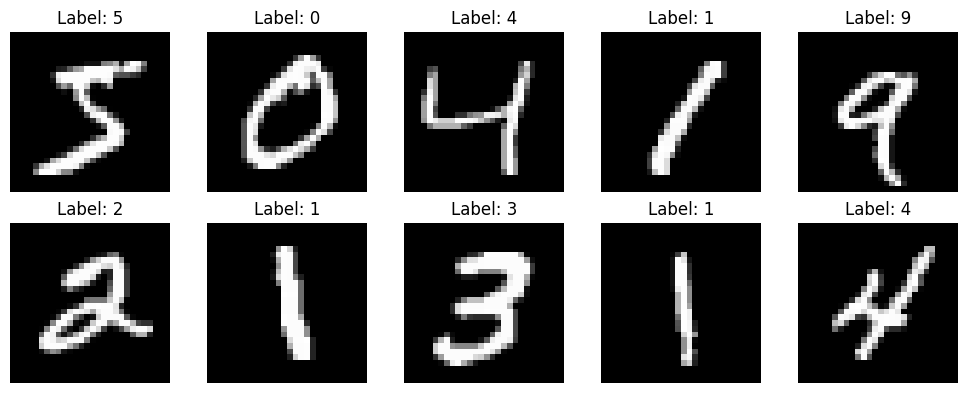

Processed x_train shape: (60000, 28, 28, 1)
Processed x_test shape: (10000, 28, 28, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 48s 106ms/step - accuracy: 0.8849 - loss: 0.3744 - val_accuracy: 0.9782 - val_loss: 0.0822
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.9653 - loss: 0.1125 - val_accuracy: 0.9830 - val_loss: 0.0574
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 78s 90ms/step - accuracy: 0.9744 - loss: 0.0848 - val_accuracy: 0.9880 - val_loss: 0.0455
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 104ms/step - accuracy: 0.9788 - loss: 0.0685 - val_accuracy: 0.9902 - val_loss: 0.0403
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 103ms/step - accuracy: 0.9816 - loss: 0.0617 - val_accuracy: 0.9907 - val_loss: 0.0380
Test loss: 0.03671388328075409
Test accuracy: 0.9883000254631042


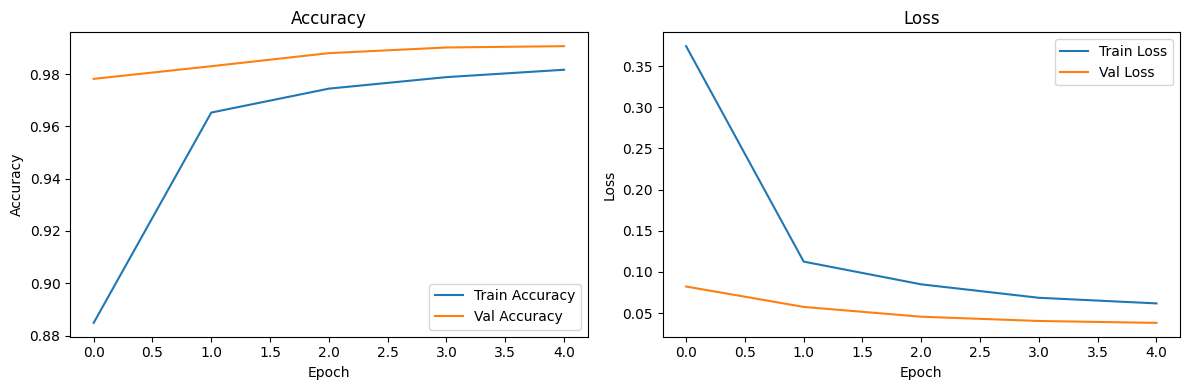

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


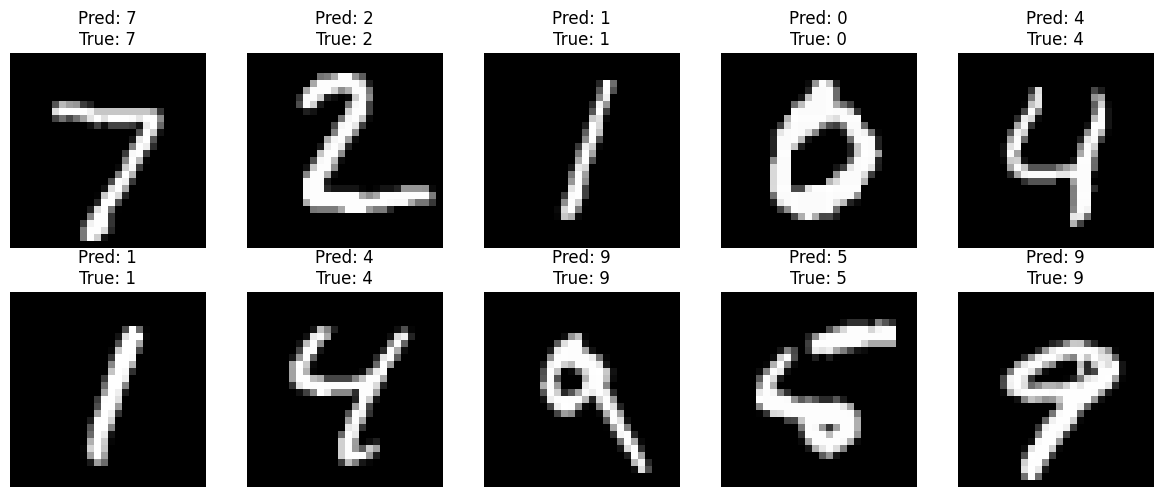

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       0.99      0.98      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [3]:
!pip install -q tensorflow matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report

# 1. Load data
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Original x_train shape:", x_train.shape)
print("Original x_test shape:", x_test.shape)

# 2. Show sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# 3. Preprocess
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Processed x_train shape:", x_train.shape)
print("Processed x_test shape:", x_test.shape)

# 4. Build CNN
num_classes = 10
input_shape = (28, 28, 1)

model = keras.Sequential([
    keras.Input(shape=input_shape),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax"),
])

model.summary()

# 5. Compile
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 6. Train
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=5,
    validation_split=0.1
)

# 7. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# 8. Plot history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# 9. Predict
pred_probs = model.predict(x_test)
y_pred = np.argmax(pred_probs, axis=1)

# 10. Show predictions
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title(f"Pred: {y_pred[i]}\nTrue: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# 11. Report
print(classification_report(y_test, y_pred))


Epoch results: what happened during training

You trained for 5 epochs.

Training accuracy

It improved from about:

88.49% in epoch 1
to

98.16% in epoch 5

That means the model kept learning better patterns from the training data.

Validation accuracy

It improved from about:

97.82%
to

99.07%

This is excellent because validation accuracy is very high and keeps improving.

Training loss

It dropped from:

0.3744
to

0.0617

Lower loss means the model’s predictions are becoming more confident and correct.

Validation loss

It dropped from:

0.0822
to

0.0380

This is also very good.
Why validation accuracy is higher than training accuracy

You may notice:

training accuracy is around 98.16%

validation accuracy is around 99.07%

That can happen because of dropout.

During training, dropout makes the task harder by randomly turning off some neurons. During validation/testing, dropout is turned off, so the network performs a bit better.

So this is not a problem here.

Test set results

You got:

Test loss: about 0.0367

Test accuracy: about 0.9883

This means the model also performs very well on completely unseen test data.

That is the most important result, because it shows the model is not just memorizing the training set.
Accuracy and loss plots
Accuracy plot

Training accuracy goes up steadily

Validation accuracy is high and stable

This suggests:

the model is learning properly

there is no strong sign of overfitting

Loss plot

Training loss drops sharply

Validation loss also drops and stays low

This is a healthy pattern.

What would be bad?

Bad signs would be:

training accuracy going up but validation accuracy going down

training loss going down but validation loss going up

That would suggest overfitting.

You do not have that problem here.
Classification report

Your classification report shows precision, recall, and F1-score are all around 0.98–1.00 for every class.

What these mean
Precision

Of all images predicted as a certain digit, how many were correct?

Example:
If precision for digit 4 is 0.99, then when the model says “this is a 4,” it is correct 99% of the time.

Recall

Of all true images of a certain digit, how many did the model find correctly?

Example:
If recall for digit 1 is 1.00, the model found essentially all the real 1s.

F1-score

A balance between precision and recall.

Since your F1-scores are around 0.98–0.99, performance is very balanced.

Support

This is just the number of test examples for each class.

For example:

digit 0 has support 980

digit 1 has support 1135

That tells you how many true samples of each digit were in the test set.